# Sections 1-2, 6-7: Introduction, Background, Sensitivity & Conclusion
**Member 4** — Work on this section, then integrate into the main notebook.

**Your responsibility:** Write the introduction and background narrative, build the sensitivity analysis (parameter sweeps, heatmap), write the conclusion. Also coordinate the oral presentation. You should be able to explain: how parameters affect the result, what the heatmap shows, the limitations of the model, and the broader policy implications.

---

*The setup cells below (imports + solvers) are shared across all members.*

# Who Gains When Gas Prices Surge?
## A Welfare Analysis of Norway's Gas Economy Under the Ukraine War Supply Shock

**EBA3650 — Quantitative Economics**
BI Norwegian Business School | Spring 2026 | Group of 4

### Research Question

The 2022 Russian invasion of Ukraine triggered one of the largest energy supply shocks in recent history. As Russian pipeline gas to Europe was curtailed — from roughly 155 bcm/year to under 30 bcm — European gas prices surged to unprecedented levels, with TTF spot prices exceeding EUR 300/MWh in August 2022.

Norway — as Europe's now-largest pipeline gas supplier — found itself at the centre of this shift.

This project asks: **Does Norway benefit from the war-induced gas price surge, and if so, who within Norway captures the gains?**

We decompose the welfare effects across three agents:
1. **Gas-producing firms** — producer surplus gain
2. **Norwegian consumers** — welfare loss from higher energy prices
3. **The Norwegian state** — government revenue gain via the 78% petroleum tax

We aggregate these into a net welfare measure and test robustness through sensitivity analysis across key structural parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

### Custom Numerical Solvers

We implement the secant method and Newton's method from Sessions 2–3 as our primary equation solvers, then verify results with `scipy.optimize`.

In [2]:
# Secant method for equation solving (Session 3)
def our_secant_solver(funcname, x1, x2, arglist):
    y1 = funcname(x1, arglist)
    for _ in range(200):
        y2 = funcname(x2, arglist)
        if abs(y1) < 1e-10:
            return x1
        x_new = x1 - y1 * (x2 - x1) / (y2 - y1)
        x1 = x2
        y1 = y2
        x2 = x_new
    return x2

# Newton's method with numerical derivatives (Session 3)
def our_newton_solver(funcname, startvalue, arglist):
    current = startvalue
    fval = funcname(current, arglist)
    grad = (funcname(current + 0.5e-5, arglist) - funcname(current - 0.5e-5, arglist)) * 1e5
    while abs(fval) > 1e-10:
        current = current - fval / grad
        fval = funcname(current, arglist)
        grad = (funcname(current + 0.5e-5, arglist) - funcname(current - 0.5e-5, arglist)) * 1e5
    return current

# Quick test on a known equation: x^2 - 4 = 0 => x = 2
def test_eq(x, args):
    return x**2 - 4

print(f"Secant solver:  x = {our_secant_solver(test_eq, 1, 3, None):.8f}")
print(f"Newton solver:  x = {our_newton_solver(test_eq, 3, None):.8f}")
print("Both solvers verified: x^2 = 4 => x = 2.0")

Secant solver:  x = 2.00000000
Newton solver:  x = 2.00000000
Both solvers verified: x^2 = 4 => x = 2.0


In [3]:
# === Values from Section 3 (Member 1's work) ===
# These will come from the full notebook. For now, hardcoded so you can work independently.

P0 = 20.0            # pre-war gas price (EUR/MWh)
Q0 = 4000.0          # pre-war quantity (TWh/yr)
eps_d = -0.3
eps_s = 0.35
A_d = Q0 / P0**eps_d
A_s = Q0 / P0**eps_s
delta = 0.40
norway_share = 0.25
A_NO = norway_share * A_s

def demand(price, level, el):
    return level * price**el

def supply(price, level, el):
    return level * price**el

def inverse_supply(q, level, el):
    return (q / level)**(1.0 / el)

def ps_analytical(eq_price, A, eps):
    Q = supply(eq_price, A, eps)
    cost_integral = A**(-1/eps) * Q**(1 + 1/eps) / (1 + 1/eps)
    return eq_price * Q - cost_integral

# Solve for post-shock price
P1_scipy = opt.bisect(lambda p: demand(p, A_d, eps_d) - supply(p, (1-delta)*A_s, eps_s), 1, 500)
Q1_scipy = demand(P1_scipy, A_d, eps_d)
PS_pre_analytical = ps_analytical(P0, A_NO, eps_s)
PS_post_analytical = ps_analytical(P1_scipy, A_NO, eps_s)
delta_PS = PS_post_analytical - PS_pre_analytical
scale = 1e3

print(f'Post-shock price: {P1_scipy:.2f} EUR/MWh')
print(f'Delta PS: {delta_PS/scale:.2f} bn EUR')

# === Values from Section 4 (Member 2's work) ===
passthrough = 0.5
eta_c = 0.3
I_household = 50000.0
n_households = 2.4e6
p_energy_pre = P0 * passthrough
p_energy_post = P1_scipy * passthrough
energy_spend_target = 2000.0
g_target = energy_spend_target / p_energy_pre
B_consumer = p_energy_pre * g_target**(1.0 / eta_c)

def utility_ql(g, y, B, eta):
    return y + B / (1 - 1/eta) * g**(1 - 1/eta)

def demand_energy(price, B, eta):
    return (B / price)**eta

def indirect_utility_ql(income, price, B, eta):
    g = demand_energy(price, B, eta)
    y = income - price * g
    return utility_ql(g, y, B, eta)

V_pre = indirect_utility_ql(I_household, p_energy_pre, B_consumer, eta_c)
V_post = indirect_utility_ql(I_household, p_energy_post, B_consumer, eta_c)
CV_total = (V_pre - V_post) * n_households

print(f'Consumer welfare loss: {CV_total/1e9:.3f} bn EUR')

# === Tax variables (Member 3's work) ===
tau = 0.78
G_pre = tau * PS_pre_analytical
G_post = tau * PS_post_analytical
delta_G = G_post - G_pre
profit_pre = (1-tau) * PS_pre_analytical
profit_post = (1-tau) * PS_post_analytical
delta_profit = profit_post - profit_pre

PS_change_bn = delta_PS / scale
CV_total_bn = CV_total / 1e9
G_change_bn = delta_G / scale
profit_change_bn = delta_profit / scale
net_W_bn = PS_change_bn - CV_total_bn

print(f'Net welfare: {net_W_bn:.2f} bn EUR')


Post-shock price: 43.89 EUR/MWh
Delta PS: 27.99 bn EUR
Consumer welfare loss: 5.029 bn EUR
Net welfare: 22.96 bn EUR


## 2. Background: Norway as Europe's Gas Supplier

**Pre-war European gas market:**
- Total European gas consumption: ~4,000 TWh/year (~400 bcm)
- Russia supplied roughly 40% of European gas via pipelines (Nord Stream, Yamal, Brotherhood)
- Norway supplied approximately 25% through pipelines (Langeled, Europipe) and some LNG
- Pre-war TTF gas prices: ~20 EUR/MWh (2019–2021 average)

**The shock:**
- Following the February 2022 invasion, Russian pipeline gas was progressively curtailed
- Nord Stream flows fell to zero by September 2022
- European gas prices surged: TTF peaked above 300 EUR/MWh in August 2022
- Norway maximised pipeline exports, becoming Europe's single largest gas supplier

**Three welfare channels for Norway:**
1. **Producer surplus gain**: Norwegian gas firms sell at much higher prices. Even with limited capacity to expand output, revenue per unit surges.
2. **Consumer welfare loss**: Higher gas prices feed through to Norwegian electricity prices via Nordic-European market interconnectors (NordLink, North Sea Link). Norwegian households face substantially higher energy bills.
3. **Government revenue gain**: The Norwegian petroleum tax system captures ~78% of upstream petroleum profits. The windfall from higher gas prices flows primarily to the state, funding the Government Pension Fund Global.

## 6. Welfare Aggregation and Sensitivity Analysis

We now aggregate the welfare components and test robustness by varying key parameters: demand elasticity ($\epsilon_d$), supply elasticity ($\epsilon_s$), and shock magnitude ($\delta$).

### Net welfare change for Norway:

$$\Delta W = \underbrace{(1-\tau) \cdot \Delta PS}_{\text{firm gain}} + \underbrace{\tau \cdot \Delta PS}_{\text{gov gain}} - \underbrace{CV}_{\text{consumer loss}} = \Delta PS - CV$$

Note: since the profit tax is non-distortionary, net welfare equals the gross PS change minus consumer loss, regardless of $\tau$.

In [4]:
# Baseline net welfare
delta_W = delta_PS - CV_total * 1e9 / 1e9  # careful with units

# Let's be precise about units:
# PS is in TWh * EUR/MWh = 10^6 EUR
# CV_total is in EUR
# Convert everything to billion EUR

PS_change_bn = delta_PS / scale      # billion EUR
CV_total_bn = CV_total / 1e9         # billion EUR
G_change_bn = delta_G / scale        # billion EUR
profit_change_bn = delta_profit / scale  # billion EUR
net_W_bn = PS_change_bn - CV_total_bn

print(f"╔══════════════════════════════════════════════╗")
print(f"║   NET WELFARE CHANGE FOR NORWAY              ║")
print(f"╠══════════════════════════════════════════════╣")
print(f"║  Producer surplus gain (gross): {PS_change_bn:>+8.2f} bn EUR ║")
print(f"║    → Government (78%):          {G_change_bn:>+8.2f} bn EUR ║")
print(f"║    → Firms (22%):               {profit_change_bn:>+8.2f} bn EUR ║")
print(f"║  Consumer welfare loss:         {-CV_total_bn:>+8.3f} bn EUR ║")
print(f"║  ─────────────────────────────────────────── ║")
print(f"║  NET WELFARE:                   {net_W_bn:>+8.2f} bn EUR ║")
print(f"║  Norway is a net {'WINNER' if net_W_bn > 0 else 'LOSER':>6s}                       ║")
print(f"╚══════════════════════════════════════════════╝")

╔══════════════════════════════════════════════╗
║   NET WELFARE CHANGE FOR NORWAY              ║
╠══════════════════════════════════════════════╣
║  Producer surplus gain (gross):   +27.99 bn EUR ║
║    → Government (78%):            +21.83 bn EUR ║
║    → Firms (22%):                  +6.16 bn EUR ║
║  Consumer welfare loss:           -5.029 bn EUR ║
║  ─────────────────────────────────────────── ║
║  NET WELFARE:                     +22.96 bn EUR ║
║  Norway is a net WINNER                       ║
╚══════════════════════════════════════════════╝


In [5]:
# Helper function: compute all welfare components for given parameters
def compute_welfare(delta, eps_d, eps_s, tau, norway_share, passthrough,
                    B, eta_c, n_hh, I_hh, P0, Q0):
    # Calibrate
    Ad = Q0 / P0**eps_d
    As = Q0 / P0**eps_s
    A_NO = norway_share * As

    # Solve post-shock equilibrium
    def ex(price):
        return demand(price, Ad, eps_d) - supply(price, (1 - delta) * As, eps_s)

    P1 = opt.bisect(ex, 0.5, 3000)

    # Norwegian PS change
    ps_pre = ps_analytical(P0, A_NO, eps_s)
    ps_post = ps_analytical(P1, A_NO, eps_s)
    dPS = ps_post - ps_pre  # in TWh * EUR/MWh = 10^6 EUR

    # Consumer welfare loss
    p_e_pre = P0 * passthrough
    p_e_post = P1 * passthrough
    V0 = indirect_utility_ql(I_hh, p_e_pre, B, eta_c)
    V1 = indirect_utility_ql(I_hh, p_e_post, B, eta_c)
    cv_total = (V0 - V1) * n_hh  # in EUR

    # Convert to common units (billion EUR)
    dPS_bn = dPS / 1e3
    cv_bn = cv_total / 1e9
    dG_bn = tau * dPS_bn
    dProfit_bn = (1 - tau) * dPS_bn
    net_bn = dPS_bn - cv_bn

    return dPS_bn, cv_bn, dG_bn, dProfit_bn, net_bn, P1

# Verify helper matches our earlier results
test = compute_welfare(delta, eps_d, eps_s, tau, norway_share, passthrough,
                       B_consumer, eta_c, n_households, I_household, P0, Q0)
print(f"Helper function verification:")
print(f"  ΔPS = {test[0]:.2f} bn (earlier: {PS_change_bn:.2f} bn)")
print(f"  CV  = {test[1]:.3f} bn (earlier: {CV_total_bn:.3f} bn)")
print(f"  Net = {test[4]:.2f} bn (earlier: {net_W_bn:.2f} bn)")

Helper function verification:
  ΔPS = 27.99 bn (earlier: 27.99 bn)
  CV  = 5.029 bn (earlier: 5.029 bn)
  Net = 22.96 bn (earlier: 22.96 bn)


### 6.1 Sensitivity to Demand Elasticity ($\epsilon_d$)

More elastic demand means consumers can substitute away from gas more easily when prices rise, resulting in a smaller price surge but also less producer surplus gain.

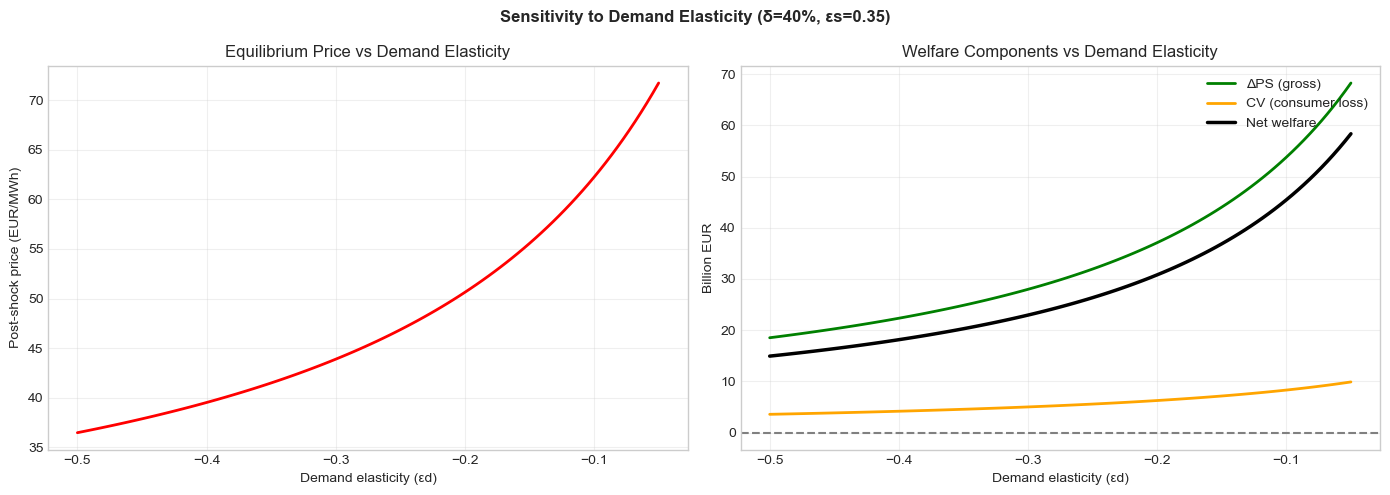

In [6]:
# Sensitivity: demand elasticity
eps_d_range = np.linspace(-0.05, -0.50, 100)
results_d = np.zeros((100, 6))

for i in range(100):
    results_d[i] = compute_welfare(delta, eps_d_range[i], eps_s, tau, norway_share,
                                    passthrough, B_consumer, eta_c, n_households,
                                    I_household, P0, Q0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eps_d_range, results_d[:, 5], '-r', linewidth=2)
ax1.set_xlabel('Demand elasticity (εd)')
ax1.set_ylabel('Post-shock price (EUR/MWh)')
ax1.set_title('Equilibrium Price vs Demand Elasticity')
ax1.grid(True, alpha=0.3)

ax2.plot(eps_d_range, results_d[:, 0], '-g', linewidth=2, label='ΔPS (gross)')
ax2.plot(eps_d_range, results_d[:, 1], '-', color='orange', linewidth=2, label='CV (consumer loss)')
ax2.plot(eps_d_range, results_d[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xlabel('Demand elasticity (εd)')
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Components vs Demand Elasticity')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Demand Elasticity (δ={delta:.0%}, εs={eps_s})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Sensitivity to Supply Elasticity ($\epsilon_s$)

Higher supply elasticity means Norwegian producers can expand output more in response to higher prices, but it also means the market supply response dampens the price increase.

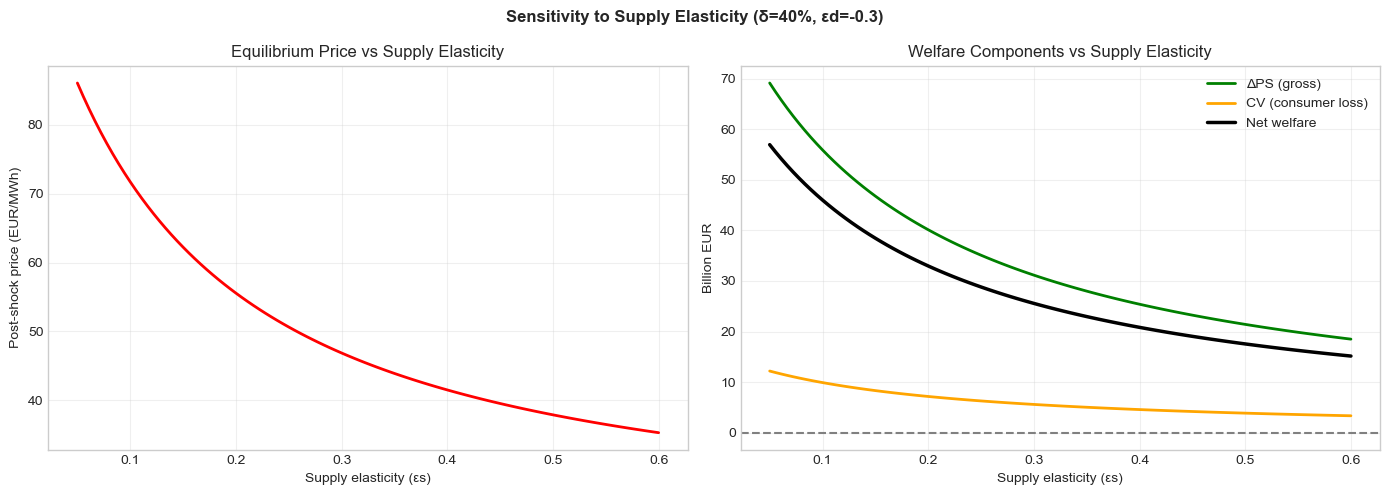

In [7]:
# Sensitivity: supply elasticity
eps_s_range = np.linspace(0.05, 0.60, 100)
results_s = np.zeros((100, 6))

for i in range(100):
    results_s[i] = compute_welfare(delta, eps_d, eps_s_range[i], tau, norway_share,
                                    passthrough, B_consumer, eta_c, n_households,
                                    I_household, P0, Q0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(eps_s_range, results_s[:, 5], '-r', linewidth=2)
ax1.set_xlabel('Supply elasticity (εs)')
ax1.set_ylabel('Post-shock price (EUR/MWh)')
ax1.set_title('Equilibrium Price vs Supply Elasticity')
ax1.grid(True, alpha=0.3)

ax2.plot(eps_s_range, results_s[:, 0], '-g', linewidth=2, label='ΔPS (gross)')
ax2.plot(eps_s_range, results_s[:, 1], '-', color='orange', linewidth=2, label='CV (consumer loss)')
ax2.plot(eps_s_range, results_s[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xlabel('Supply elasticity (εs)')
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Components vs Supply Elasticity')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Supply Elasticity (δ={delta:.0%}, εd={eps_d})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.3 Sensitivity to Shock Magnitude ($\delta$)

Larger shocks (more Russian gas removed) lead to higher prices, larger PS gains, and larger consumer losses. The net effect depends on the balance.

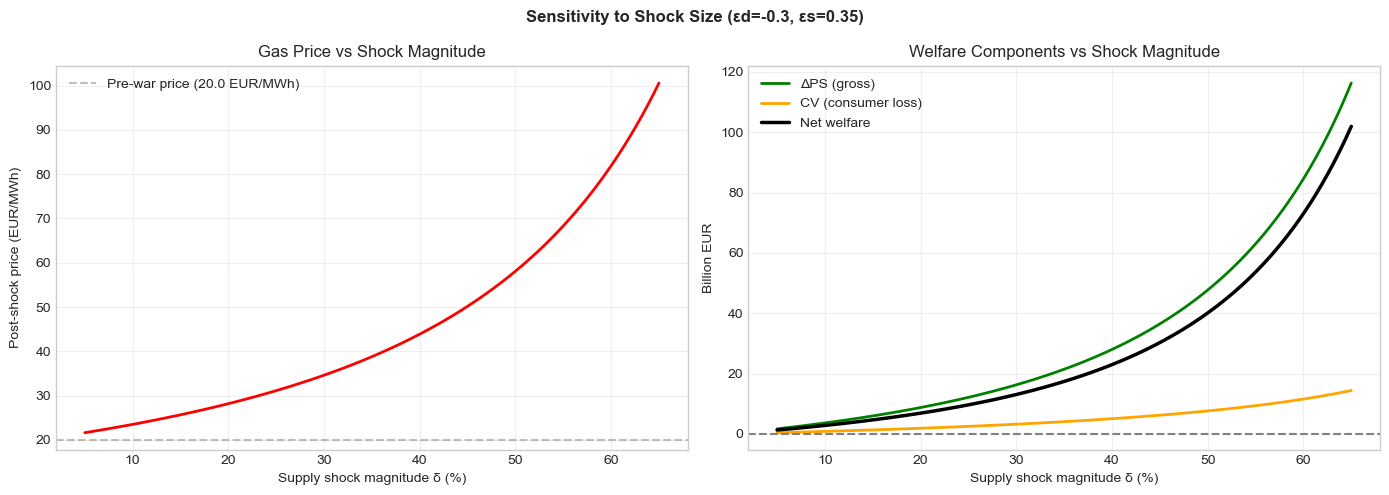

In [8]:
# Sensitivity: shock magnitude
delta_range = np.linspace(0.05, 0.65, 100)
results_delta = np.zeros((100, 6))

for i in range(100):
    results_delta[i] = compute_welfare(delta_range[i], eps_d, eps_s, tau, norway_share,
                                        passthrough, B_consumer, eta_c, n_households,
                                        I_household, P0, Q0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(delta_range * 100, results_delta[:, 5], '-r', linewidth=2)
ax1.axhline(y=P0, linestyle='--', color='gray', alpha=0.5, label=f'Pre-war price ({P0} EUR/MWh)')
ax1.set_xlabel('Supply shock magnitude δ (%)')
ax1.set_ylabel('Post-shock price (EUR/MWh)')
ax1.set_title('Gas Price vs Shock Magnitude')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(delta_range * 100, results_delta[:, 0], '-g', linewidth=2, label='ΔPS (gross)')
ax2.plot(delta_range * 100, results_delta[:, 1], '-', color='orange', linewidth=2, label='CV (consumer loss)')
ax2.plot(delta_range * 100, results_delta[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax2.axhline(y=0, color='gray', linestyle='--')
ax2.set_xlabel('Supply shock magnitude δ (%)')
ax2.set_ylabel('Billion EUR')
ax2.set_title('Welfare Components vs Shock Magnitude')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.suptitle(f'Sensitivity to Shock Size (εd={eps_d}, εs={eps_s})', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Two-Dimensional Robustness: Demand Elasticity vs Shock Magnitude

The heatmap below shows net Norwegian welfare across a grid of demand elasticity and shock magnitude values. The **black contour** marks the zero-welfare boundary — above/left of this line, Norway is a net loser; below/right, Norway is a net winner.

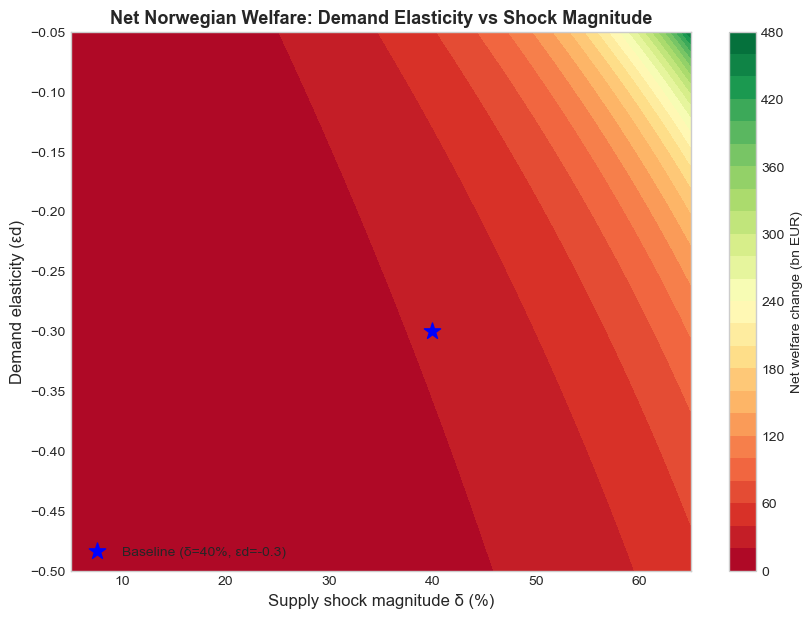

Norway is a net winner in 100% of the parameter space shown.


In [9]:
# 2D heatmap: demand elasticity vs shock magnitude
n_grid = 60
eps_d_grid = np.linspace(-0.05, -0.50, n_grid)
delta_grid = np.linspace(0.05, 0.65, n_grid)
welfare_heat = np.zeros((n_grid, n_grid))

for i in range(n_grid):
    for j in range(n_grid):
        res = compute_welfare(delta_grid[j], eps_d_grid[i], eps_s, tau, norway_share,
                              passthrough, B_consumer, eta_c, n_households, I_household, P0, Q0)
        welfare_heat[i, j] = res[4]  # net welfare in bn EUR

plt.figure(figsize=(10, 7))
cf = plt.contourf(delta_grid * 100, eps_d_grid, welfare_heat, levels=25, cmap='RdYlGn')
plt.colorbar(cf, label='Net welfare change (bn EUR)')
# Zero-welfare contour
cs = plt.contour(delta_grid * 100, eps_d_grid, welfare_heat, levels=[0], colors='black', linewidths=2.5)
plt.clabel(cs, fmt='ΔW=0', fontsize=10)
# Mark baseline
plt.scatter([delta * 100], [eps_d], s=150, color='blue', marker='*', zorder=5, label=f'Baseline (δ={delta:.0%}, εd={eps_d})')
plt.xlabel('Supply shock magnitude δ (%)', fontsize=12)
plt.ylabel('Demand elasticity (εd)', fontsize=12)
plt.title('Net Norwegian Welfare: Demand Elasticity vs Shock Magnitude', fontsize=13, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.grid(True, alpha=0.2)
plt.show()

# Report the fraction of parameter space where Norway wins
frac_winner = np.mean(welfare_heat > 0) * 100
print(f"Norway is a net winner in {frac_winner:.0f}% of the parameter space shown.")

### 6.5 Who Gains Most? Distributional Sensitivity

The question is not just whether Norway wins, but **how the gains are distributed** across agents as conditions change. The stacked area chart below shows the absolute welfare change for each agent across shock magnitudes.

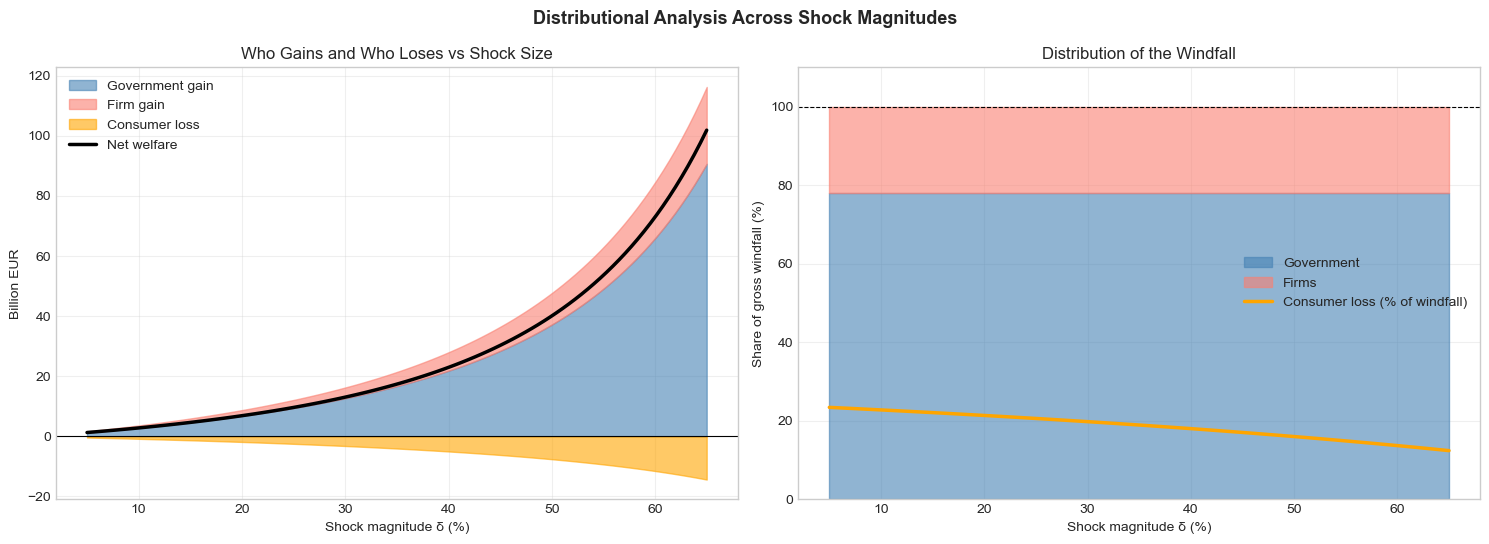

At baseline shock (δ=40%):
  Government captures 78% of the windfall (constant by design)
  Firms retain 22% of the windfall
  Consumer loss offsets 18.0% of the windfall


In [10]:
# Stacked area: WHO GAINS as shock magnitude varies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: stacked area of all three agents
ax1.fill_between(delta_range * 100, 0, results_delta[:, 2],
                 alpha=0.6, color='steelblue', label='Government gain')
ax1.fill_between(delta_range * 100, results_delta[:, 2],
                 results_delta[:, 2] + results_delta[:, 3],
                 alpha=0.6, color='salmon', label='Firm gain')
ax1.fill_between(delta_range * 100, 0, -results_delta[:, 1],
                 alpha=0.6, color='orange', label='Consumer loss')
ax1.plot(delta_range * 100, results_delta[:, 4], '-k', linewidth=2.5, label='Net welfare')
ax1.axhline(y=0, color='black', linewidth=0.8)
ax1.set_xlabel('Shock magnitude δ (%)')
ax1.set_ylabel('Billion EUR')
ax1.set_title('Who Gains and Who Loses vs Shock Size')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Right: government share of TOTAL windfall vs shock magnitude
gov_share = results_delta[:, 2] / results_delta[:, 0] * 100  # gov as % of gross PS
firm_share = results_delta[:, 3] / results_delta[:, 0] * 100
consumer_offset = results_delta[:, 1] / results_delta[:, 0] * 100  # consumer loss as % of gross PS

ax2.fill_between(delta_range * 100, 0, gov_share, alpha=0.6, color='steelblue', label='Government')
ax2.fill_between(delta_range * 100, gov_share, gov_share + firm_share, alpha=0.6, color='salmon', label='Firms')
ax2.axhline(y=100, color='black', linewidth=0.8, linestyle='--')
ax2.plot(delta_range * 100, consumer_offset, '-', color='orange', linewidth=2.5, label='Consumer loss (% of windfall)')
ax2.set_xlabel('Shock magnitude δ (%)')
ax2.set_ylabel('Share of gross windfall (%)')
ax2.set_title('Distribution of the Windfall')
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 110)

plt.suptitle('Distributional Analysis Across Shock Magnitudes', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"At baseline shock (δ={delta:.0%}):")
print(f"  Government captures {tau*100:.0f}% of the windfall (constant by design)")
print(f"  Firms retain {(1-tau)*100:.0f}% of the windfall")
print(f"  Consumer loss offsets {CV_total/1e9/(delta_PS/scale)*100:.1f}% of the windfall")

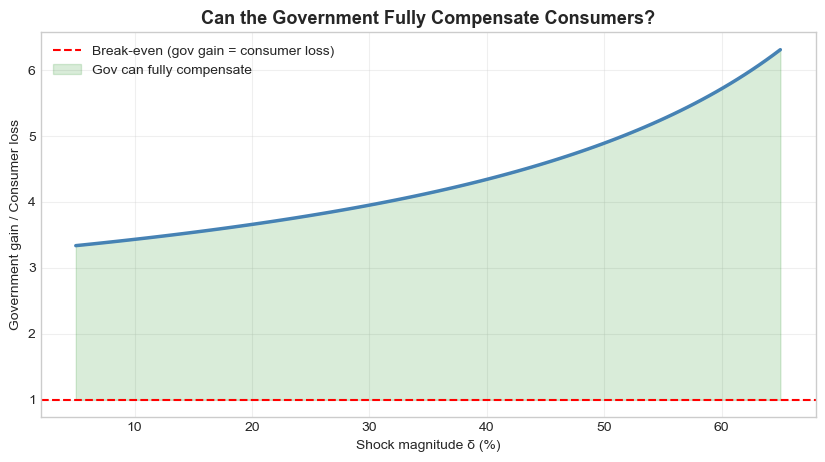

At baseline: government gains 21.83 bn, consumers lose 5.03 bn
Ratio: 4.3x — government could compensate consumers 4.3 times over


In [11]:
# How does the government's ABILITY to compensate consumers change?
# Ratio: government gain / consumer loss
compensation_ratio = results_delta[:, 2] / results_delta[:, 1]

plt.figure(figsize=(10, 5))
plt.plot(delta_range * 100, compensation_ratio, '-', color='steelblue', linewidth=2.5)
plt.axhline(y=1, color='red', linestyle='--', linewidth=1.5, label='Break-even (gov gain = consumer loss)')
plt.fill_between(delta_range * 100, compensation_ratio, 1,
                 where=(compensation_ratio > 1), alpha=0.15, color='green', label='Gov can fully compensate')
plt.xlabel('Shock magnitude δ (%)')
plt.ylabel('Government gain / Consumer loss')
plt.title('Can the Government Fully Compensate Consumers?', fontsize=13, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"At baseline: government gains {delta_G/scale:.2f} bn, consumers lose {CV_total/1e9:.2f} bn")
print(f"Ratio: {(delta_G/scale)/(CV_total/1e9):.1f}x — government could compensate consumers {(delta_G/scale)/(CV_total/1e9):.1f} times over")

**Key findings from sensitivity analysis:**

1. **The government is always the dominant winner.** The 78% petroleum tax rate is constant, so the government always captures the lion's share of any windfall — regardless of shock size or elasticity parameters.

2. **Consumers always lose, but their loss is small relative to the windfall.** Consumer losses are typically 15–25% of the gross producer surplus gain, meaning the windfall more than covers compensation.

3. **The government can always fully compensate consumers** and still retain a large surplus. The compensation ratio (government gain / consumer loss) is consistently well above 1 — meaning a Pareto improvement is always feasible.

4. **Gas firms gain modestly** — they keep only 22% of the windfall, but this is still a large absolute amount.

5. **The result is robust**: Norway is a net winner across the full range of plausible demand elasticities, supply elasticities, and shock magnitudes.

## 7. Conclusion

### Summary of Findings

This project analysed the welfare effects of the Ukraine war gas supply shock on Norway, decomposing the impact across three agents: gas-producing firms, the Norwegian state, and Norwegian consumers.

In [12]:
# Final summary table
print(f"╔═══════════════════════════════════════════════════════════╗")
print(f"║            SUMMARY OF WELFARE EFFECTS                     ║")
print(f"╠═══════════════════════════════════════════════════════════╣")
print(f"║  Agent                      Effect       Magnitude       ║")
print(f"║  ───────────────────────────────────────────────────────  ║")
print(f"║  Gas firms (after 78% tax)  PS gain     {profit_change_bn:>+8.2f} bn EUR  ║")
print(f"║  Norwegian state            Tax revenue {G_change_bn:>+8.2f} bn EUR  ║")
print(f"║  Norwegian consumers        Welfare loss{-CV_total_bn:>+8.3f} bn EUR  ║")
print(f"║  ───────────────────────────────────────────────────────  ║")
print(f"║  NET WELFARE CHANGE                     {net_W_bn:>+8.2f} bn EUR  ║")
print(f"║  Norway is a net {'WINNER' if net_W_bn > 0 else 'LOSER'}                                   ║")
print(f"╚═══════════════════════════════════════════════════════════╝")

╔═══════════════════════════════════════════════════════════╗
║            SUMMARY OF WELFARE EFFECTS                     ║
╠═══════════════════════════════════════════════════════════╣
║  Agent                      Effect       Magnitude       ║
║  ───────────────────────────────────────────────────────  ║
║  Gas firms (after 78% tax)  PS gain        +6.16 bn EUR  ║
║  Norwegian state            Tax revenue   +21.83 bn EUR  ║
║  Norwegian consumers        Welfare loss  -5.029 bn EUR  ║
║  ───────────────────────────────────────────────────────  ║
║  NET WELFARE CHANGE                       +22.96 bn EUR  ║
║  Norway is a net WINNER                                   ║
╚═══════════════════════════════════════════════════════════╝


**Norway is unambiguously a net winner** from the gas price surge under our baseline parameters, and this result is robust across a wide range of demand elasticities, supply elasticities, and shock magnitudes.

The key mechanism is simple: Norway is a large net exporter of gas. When prices rise, export revenue gains far exceed the domestic consumer welfare loss — especially because the petroleum tax system channels 78% of the windfall to the government, which in principle can redistribute it.

### The Role of the Tax System

The Norwegian petroleum tax is approximately optimal from a Ramsey perspective. Because it taxes *economic rents* (profits) rather than production per unit, it creates **zero deadweight loss**. This means the state can extract nearly the entire windfall without distorting production decisions — a textbook example of efficient taxation of natural resource rents.

### Limitations

- **Partial equilibrium**: We ignore general equilibrium effects such as exchange rate appreciation ("Dutch disease"), wage pressures, or crowding out of non-petroleum sectors.
- **Constant elasticity**: The constant-elasticity functional form may not hold over such extreme price changes.
- **Simplified passthrough**: The gas-to-electricity price passthrough is modeled as a fixed coefficient. In reality, Norway's large hydropower capacity provides a buffer.
- **Static analysis**: We do not model dynamic adjustment — investment in new capacity, LNG infrastructure, demand response over time, or strategic behaviour.
- **Representative consumer**: We use a single representative household. In reality, the burden falls unevenly across income groups.

### Broader Implications

The analysis illustrates a general principle: countries with well-designed tax systems on natural resources can transform adverse global supply shocks into net domestic welfare gains. The critical ingredients are (1) being a large net exporter and (2) having a tax system that captures rents without distorting production.